# SIREN model diagnostics

Diagnostic notebook for the parameter-space classifier pipeline:

- **Section 1** applies the diagnostic recipe from `to_do/chat.md` to the vanilla SIREN backbone — weight spectra, pre/post-sine activation distributions, coordinate-scale audit, function sharpness, reconstruction fidelity curve.
- **Section 2** runs the same battery on the soft-Lipschitz checkpoint and overlays the two models so the comparison is direct.
- **Section 3** probes perturbation sensitivity: (3.1) random-noise shift curves over the standard $\varepsilon$ grid, (3.2) per-step PGD telemetry, (3.3) 2D decision-boundary slice.
- **Section 4** auto-populates a vanilla-vs-softlip summary table.

Heavy cells (PGD + boundary slice) are guarded by `RUN_HEAVY`. Set it to `True` once the lighter diagnostics look sane.

**Conventions.** All paths in §0 are top-of-notebook variables — repoint them without editing code. Fitting procedure matches `makeset.py` (SGD, lr 0.01, no grad clipping) so any `iters=5` number is apples-to-apples with what the downstream classifier sees.

## 0. Setup

Imports, path setup, configuration knobs, shared helpers. Run these cells first; nothing below will work without them.

In [1]:
"""0.1 Imports and path setup.

The notebook lives under SIREN_Vista/notebooks/ but imports modules from
SIREN_Vista/ directly. We prepend the repo root to sys.path so that
`import SIREN`, `import variants`, etc. resolve.
"""
import os
import sys
import json
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() \
    else Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPO_ROOT = REPO_ROOT.resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from SIREN import ModulatedSIREN, SineAffine, SinActivation  # noqa: E402
from train_classifier import Classifier                       # noqa: E402
from dataloader import get_mnist_loader                       # noqa: E402
from diagnostics import layer_sigmas                          # noqa: E402
from evaluate_reconstruction import batched_forward, ssim_2d_batch  # noqa: E402
import variants                                               # noqa: E402

print("repo root :", REPO_ROOT)
# Avoid touching CUDA here — §0.2 sets CUDA_VISIBLE_DEVICES first; otherwise the
# first visible GPU is locked in for the whole kernel.
print("torch     :", torch.__version__, "| (cuda visibility configured in §0.2)")
print("variants  :", variants.available())

repo root : /home/omarg/SIREN_Vista
torch     : 2.0.1+cu117 | (cuda visibility configured in §0.2)
variants  : ['soft_lipschitz', 'vanilla']


In [2]:
"""0.2 Configuration.

Every path and size knob the notebook needs. Repoint any of these without
editing code further down.

This copy is configured for the completed hardcap90 soft-Lipschitz run:

- SIREN checkpoint:
  `model_mnist/softlip_L1_lam1e+00_sine_and_readout/modSiren.pth`
- Run artifacts:
  `runs/softlip_hardcap90_lam1e+00_sine_and_readout/`

The checkpoint was trained before `--model-name` was added, so the model
checkpoint directory and the run-artifact directory intentionally have
different names.
"""
# ---- GPU (physical index) -------------------------------------------------
# Set *before* any CUDA tensors are created. Default 1 = second GPU on this
# machine (card 0 is the first). After this, PyTorch sees a single device as
# ``cuda:0`` — that logical GPU is your chosen physical card.
CUDA_DEVICE_ID = 1
os.environ["CUDA_VISIBLE_DEVICES"] = str(CUDA_DEVICE_ID)

# ---- checkpoints --------------------------------------------------------
VANILLA_CKPT = REPO_ROOT / "model_mnist" / "vanilla" / "modSiren.pth"
VANILLA_CKPT_FALLBACK = Path("/home/omarg/SIREN_Vista/model_mnist/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/modSiren.pth")

# hardcap90 SIREN checkpoint saved under the pre---model-name variant slug.
SOFTLIP_CKPT = REPO_ROOT / "model_mnist" / "softlip_L1_lam1e+00_sine_and_readout" / "modSiren.pth"

# Classifier paths -- trained on the *matching* functaset produced by makeset.py.
VANILLA_CLASSIFIER = REPO_ROOT / "runs" / "vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256" / "mnist_classifier" / "best_classifier.pth"
SOFTLIP_CLASSIFIER = REPO_ROOT / "runs" / "softlip_hardcap90_lam1e+00_sine_and_readout" / "mnist_classifier" / "best_classifier.pth"

# Optional artifact path for sanity checks / later report updates.
SOFTLIP_RECON_EVAL = REPO_ROOT / "runs" / "softlip_hardcap90_lam1e+00_sine_and_readout" / "reconstruction_eval.json"

# ---- soft-Lipschitz hyperparameters (for cap overlay in §2.1) -----------
# Read from the checkpoint's `variant_args` when available; these defaults
# match the hardcap90 checkpoint metadata (L kept for the CLI, apply_to is
# sine + readout, and sine.0 was not skipped).
SOFTLIP_L_DEFAULT          = 1.0
SOFTLIP_APPLY_TO_DEFAULT   = "sine_and_readout"
SOFTLIP_SKIP_FIRST_DEFAULT = False

# ---- model architecture (used only if a checkpoint omits `model_args`) --
SIREN_HIDDEN_DEFAULT = 256
SIREN_DEPTH_DEFAULT  = 10
SIREN_MODDIM_DEFAULT = 512
SIREN_FREQ_DEFAULT   = 30.0
CLF_WIDTH_DEFAULT    = 512
CLF_DEPTH_DEFAULT    = 3

# ---- data / device ------------------------------------------------------
DATA_ROOT   = REPO_ROOT.parent  # /home/omarg -> MNIST expects ../data from here
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
SEED        = 0

# ---- sample / grid sizes ------------------------------------------------
N_DIAG_SAMPLES    = 8    # images used in §1.2, §1.4, §2.2, §2.3
N_FIDELITY_IMAGES = 64   # images used in the PSNR vs iters curves (§1.5, §2.5)
N_PERT_SAMPLES    = 16   # §3.1 random-noise sensitivity
N_PGD_SAMPLES     = 4    # §3.2 PGD trajectory (one plot per sample)
N_BOUNDARY_GRID   = 21   # §3.3: 21x21 = 441 fits per model per anchor

# inner-loop budget for all "short" fits. Matches makeset --iters 5 default
FIT_STEPS_FAST  = 5
FIT_STEPS_SLOW  = 200  # fidelity ceiling
FIT_LR          = 0.01

# ---- heavy-cell toggle --------------------------------------------------
RUN_HEAVY = True  # flip to True to run §3.2 PGD and §3.3 boundary slice

torch.manual_seed(SEED)
np.random.seed(SEED)
if DEVICE == "cuda":
    print(
        f"CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES', '')!r} "
        f"(physical GPU index was CUDA_DEVICE_ID={CUDA_DEVICE_ID})"
    )
    print(f"  logical GPUs visible to PyTorch: {torch.cuda.device_count()}")
    print(f"  cuda:0 -> {torch.cuda.get_device_name(0)}")
print(f"DEVICE={DEVICE} SEED={SEED} RUN_HEAVY={RUN_HEAVY}")

CUDA_VISIBLE_DEVICES='1' (physical GPU index was CUDA_DEVICE_ID=1)
  logical GPUs visible to PyTorch: 1
  cuda:0 -> NVIDIA GeForce RTX 2080 Ti
DEVICE=cuda SEED=0 RUN_HEAVY=True


In [3]:
"""0.3 Shared helpers.

- load_siren / load_classifier : variant-aware checkpoint loading
- fit_phi                     : single-image inner loop (optionally with trajectory)
- batched_fit_phi             : B-image inner loop (reuses evaluate_reconstruction.batched_forward)
- hooked_forward              : context manager that captures pre-/post-sine
                                activations via forward hooks on SinActivation
- plotting helpers            : histogram grid, sigma bar, sensitivity curve
"""

# ---- checkpoint loading -------------------------------------------------
def _resolve_ckpt(primary, fallback=None):
    primary = Path(primary)
    if primary.exists():
        return primary
    if fallback is not None and Path(fallback).exists():
        print(f"[load] primary '{primary}' missing, falling back to '{fallback}'")
        return Path(fallback)
    return None


def load_siren(ckpt_path, device=DEVICE, height=28, width=28, voxels=False):
    """Load a ModulatedSIREN from a checkpoint produced by trainer.py.

    Uses `model_args` and `variant` / `variant_args` from the checkpoint
    when present; falls back to the module-level defaults otherwise.
    Returns (model, meta) where meta is a dict of the recovered metadata.
    """
    if ckpt_path is None:
        return None, None
    ckpt = torch.load(ckpt_path, map_location=device)
    model_args = ckpt.get("model_args", {}) or {}
    hidden = model_args.get("hidden_dim", SIREN_HIDDEN_DEFAULT)
    depth  = model_args.get("depth",       SIREN_DEPTH_DEFAULT)
    moddim = model_args.get("mod_dim",     SIREN_MODDIM_DEFAULT)
    model = ModulatedSIREN(
        height=height, width=width,
        hidden_features=hidden, num_layers=depth,
        modul_features=moddim, device=device,
    ).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)
    meta = {
        "variant":      ckpt.get("variant", "vanilla"),
        "variant_args": ckpt.get("variant_args", {}) or {},
        "model_args":   {"hidden_dim": hidden, "depth": depth, "mod_dim": moddim},
        "loss":         ckpt.get("loss"),
        "epoch":        ckpt.get("epoch"),
        "path":         str(ckpt_path),
    }
    return model, meta


def load_classifier(ckpt_path, in_features, device=DEVICE,
                    width=CLF_WIDTH_DEFAULT, depth=CLF_DEPTH_DEFAULT, num_classes=10):
    """Load a downstream Classifier MLP from train_classifier.py.

    `in_features` must match the SIREN's modul_features.
    """
    if ckpt_path is None or not Path(ckpt_path).exists():
        return None
    ckpt = torch.load(ckpt_path, map_location=device)
    sd = ckpt.get("state_dict", ckpt)
    clf = Classifier(width=width, depth=depth,
                     in_features=in_features, num_classes=num_classes).to(device)
    clf.load_state_dict(sd)
    clf.eval()
    for p in clf.parameters():
        p.requires_grad_(False)
    return clf


# ---- inner-loop fitting -------------------------------------------------
def fit_phi(model, image_flat, steps=FIT_STEPS_FAST, lr=FIT_LR,
            start_mod=None, trajectory=False, device=DEVICE):
    """Single-image inner fit, mirroring makeset.create_functaset.

    Args:
        image_flat: (H*W,) or (H*W,1) pixel target in [0, 1].
        start_mod : optional warm-start modulation (else zeros).
        trajectory: if True, returns a list of phi snapshots + a list of
            per-step MSE, in addition to the final phi.
    """
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    tgt = image_flat.to(device).view(-1, 1).float()

    if start_mod is None:
        phi = torch.zeros(model.modul_features, device=device)
    else:
        phi = start_mod.detach().clone().to(device).float()
    phi.requires_grad_(True)
    opt = optim.SGD([phi], lr=lr)
    mses, traj = [], []

    for _ in range(steps):
        opt.zero_grad()
        fitted = model(phi)
        loss = ((fitted - tgt) ** 2).mean()
        loss.backward()
        opt.step()
        mses.append(float(loss.item()))
        if trajectory:
            traj.append(phi.detach().clone())
    if trajectory:
        return phi.detach(), mses, traj
    return phi.detach(), mses


def batched_fit_phi(model, images_flat, steps=FIT_STEPS_FAST, lr=FIT_LR, device=DEVICE):
    """Fit B modulations in parallel via evaluate_reconstruction.batched_forward.

    Args:
        images_flat: (B, H*W) target pixels in [0, 1].
    Returns:
        phi_batch: (B, modul_features)
        mse_per  : (B,)  final per-image MSE
    """
    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    tgt = images_flat.to(device).float()
    B = tgt.shape[0]
    tgt_for_loss = tgt.view(B, -1, 1)

    phi = torch.zeros(B, model.modul_features, device=device, requires_grad=True)
    opt = optim.SGD([phi], lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        fitted = batched_forward(model, phi)  # (B, N, 1)
        per_img = ((fitted - tgt_for_loss) ** 2).mean(dim=(1, 2))
        per_img.sum().backward()
        opt.step()
    with torch.no_grad():
        fitted = batched_forward(model, phi)
        per_img = ((fitted - tgt_for_loss) ** 2).mean(dim=(1, 2))
    return phi.detach(), per_img.detach()


# ---- activation hooks ---------------------------------------------------
@contextmanager
def hooked_forward(model):
    """Register forward hooks on every SinActivation and SineAffine.affine
    so that pre-sine z_l = freq*(W x + b + shift) and post-sine sin(z_l)
    can be inspected after a forward pass.

    Usage:
        with hooked_forward(model) as buf:
            _ = model(phi)
        # buf['sine.0.pre'], buf['sine.0.post'], buf['sine.0.affine']

    SinActivation is an explicit submodule on every SineAffine precisely
    so these hooks can be attached (see SIREN.py:6).
    """
    buf = {}
    handles = []
    sine_idx = 0
    for m in model.modules():
        if isinstance(m, SineAffine):
            idx = sine_idx
            affine = m.affine
            act    = m.activation
            def _mk_affine_hook(i):
                def _h(mod, inp, out):
                    buf[f"sine.{i}.affine"] = out.detach().clone()
                return _h
            def _mk_act_hook(i):
                def _h(mod, inp, out):
                    buf[f"sine.{i}.pre"]  = inp[0].detach().clone()
                    buf[f"sine.{i}.post"] = out.detach().clone()
                return _h
            handles.append(affine.register_forward_hook(_mk_affine_hook(idx)))
            handles.append(act   .register_forward_hook(_mk_act_hook(idx)))
            sine_idx += 1
    try:
        yield buf
    finally:
        for h in handles:
            h.remove()


# ---- plotting helpers ---------------------------------------------------
def _new_fig(rows=1, cols=1, figsize=None):
    if figsize is None:
        figsize = (4 * cols, 3 * rows)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    return fig, axes


def _psnr_from_mse(mse):
    mse = np.asarray(mse, dtype=np.float64)
    mse = np.clip(mse, 1e-12, None)
    return 10.0 * np.log10(1.0 / mse)


print("helpers loaded:",
      [f for f in ("load_siren","load_classifier","fit_phi","batched_fit_phi","hooked_forward") if f in globals()])

helpers loaded: ['load_siren', 'load_classifier', 'fit_phi', 'batched_fit_phi', 'hooked_forward']


In [4]:
"""0.4 Load models + a small MNIST slice that the rest of the notebook reuses.

We load:
    - vanilla SIREN + classifier (if available)
    - softlip SIREN  + classifier (if available)
    - a deterministic handful of MNIST test images for per-sample plots
    - a larger slice for the fidelity curve and sensitivity plots

None of the later cells crash if a model is missing; they just skip
their "softlip" panel or print a notice.
"""
# ---- models -------------------------------------------------------------
_v_path = _resolve_ckpt(VANILLA_CKPT, VANILLA_CKPT_FALLBACK)
_s_path = _resolve_ckpt(SOFTLIP_CKPT)

vanilla, vanilla_meta = load_siren(_v_path)
softlip, softlip_meta = load_siren(_s_path)

if vanilla is not None:
    print(f"[vanilla] loaded {vanilla_meta['variant']}  "
          f"hidden={vanilla_meta['model_args']['hidden_dim']} "
          f"depth={vanilla_meta['model_args']['depth']} "
          f"mod={vanilla_meta['model_args']['mod_dim']}  "
          f"path={vanilla_meta['path']}")
else:
    print(f"[vanilla] MISSING — looked at {VANILLA_CKPT} and {VANILLA_CKPT_FALLBACK}")

if softlip is not None:
    print(f"[softlip] loaded {softlip_meta['variant']}  "
          f"hidden={softlip_meta['model_args']['hidden_dim']} "
          f"depth={softlip_meta['model_args']['depth']} "
          f"mod={softlip_meta['model_args']['mod_dim']}  "
          f"variant_args={softlip_meta['variant_args']}")
else:
    print(f"[softlip] MISSING at {SOFTLIP_CKPT} — §2 and §3's softlip panel will be skipped")

# ---- classifiers (only needed for §3) -----------------------------------
vanilla_clf = load_classifier(VANILLA_CLASSIFIER,
                              in_features=vanilla_meta["model_args"]["mod_dim"]) \
              if vanilla is not None else None
softlip_clf = load_classifier(SOFTLIP_CLASSIFIER,
                              in_features=softlip_meta["model_args"]["mod_dim"]) \
              if softlip is not None else None
print(f"[clf] vanilla_clf={'ok' if vanilla_clf else 'missing'}  "
      f"softlip_clf={'ok' if softlip_clf else 'missing'}")

# ---- a deterministic MNIST slice ----------------------------------------
_loader = get_mnist_loader(root=str(DATA_ROOT / "data"), train=False,
                           batch_size=N_FIDELITY_IMAGES, num_workers=0,
                           pin_memory=False)
_batch_img, _batch_lbl = next(iter(_loader))
mnist_images = _batch_img.squeeze(1).to(DEVICE)   # (N_FIDELITY_IMAGES, 28, 28)
mnist_labels = _batch_lbl.to(DEVICE)              # (N_FIDELITY_IMAGES,)

diag_images = mnist_images[:N_DIAG_SAMPLES]       # (N_DIAG_SAMPLES, 28, 28)
diag_labels = mnist_labels[:N_DIAG_SAMPLES]
print(f"[data] diag={tuple(diag_images.shape)} fidelity={tuple(mnist_images.shape)}")

[load] primary '/home/omarg/SIREN_Vista/model_mnist/vanilla/modSiren.pth' missing, falling back to '/home/omarg/SIREN_Vista/model_mnist/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/modSiren.pth'
[vanilla] loaded vanilla  hidden=256 depth=10 mod=512  path=/home/omarg/SIREN_Vista/model_mnist/vanilla_e40_lr0.01_cw512_md512_do0p2_cd3_bs256/modSiren.pth
[softlip] loaded soft_lipschitz  hidden=256 depth=10 mod=512  variant_args={'soft_lip_cap': 1.0, 'soft_lip_lambda': 1.0, 'soft_lip_apply_to': 'sine_and_readout', 'soft_lip_power_iters': 1, 'soft_lip_skip_first': False}
[clf] vanilla_clf=ok  softlip_clf=ok
[data] diag=(8, 28, 28) fidelity=(64, 28, 28)


/home/omarg/miniforge3/envs/pss/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [5]:
# ---- Debug soft-Lipschitz configuration ----

DEBUG_OUTER_STEPS = 5
DEBUG_BATCH_SIZE = 4
DEBUG_INNER_STEPS = 3
DEBUG_INNER_LR = 0.01
DEBUG_OUTER_LR = 1e-4
DEBUG_TOPK_SINGULARS = 5

DEBUG_SOFT_LIP_CAP = 0.05
DEBUG_SOFT_LIP_LAMBDA = 1.0
DEBUG_SOFT_LIP_APPLY_TO = "all"
DEBUG_SOFT_LIP_SKIP_FIRST = True
DEBUG_SOFT_LIP_POWER_ITERS = 5

DEBUG_START_FROM = "vanilla"       # "vanilla" or "softlip"

# New:
DEBUG_LOSS_MODE = "penalty_only"   # "total", "penalty_only", or "mse_only"

print("Debug configuration loaded")
print(f"DEBUG_START_FROM={DEBUG_START_FROM}")
print(f"DEBUG_LOSS_MODE={DEBUG_LOSS_MODE}")
print(f"DEBUG_OUTER_STEPS={DEBUG_OUTER_STEPS}")
print(f"DEBUG_BATCH_SIZE={DEBUG_BATCH_SIZE}")
print(f"DEBUG_INNER_STEPS={DEBUG_INNER_STEPS}")
print(f"DEBUG_INNER_LR={DEBUG_INNER_LR}")
print(f"DEBUG_OUTER_LR={DEBUG_OUTER_LR}")
print(f"DEBUG_SOFT_LIP_CAP={DEBUG_SOFT_LIP_CAP}")
print(f"DEBUG_SOFT_LIP_LAMBDA={DEBUG_SOFT_LIP_LAMBDA}")
print(f"DEBUG_SOFT_LIP_APPLY_TO={DEBUG_SOFT_LIP_APPLY_TO}")
print(f"DEBUG_SOFT_LIP_SKIP_FIRST={DEBUG_SOFT_LIP_SKIP_FIRST}")

Debug configuration loaded
DEBUG_START_FROM=vanilla
DEBUG_LOSS_MODE=penalty_only
DEBUG_OUTER_STEPS=5
DEBUG_BATCH_SIZE=4
DEBUG_INNER_STEPS=3
DEBUG_INNER_LR=0.01
DEBUG_OUTER_LR=0.0001
DEBUG_SOFT_LIP_CAP=0.05
DEBUG_SOFT_LIP_LAMBDA=1.0
DEBUG_SOFT_LIP_APPLY_TO=all
DEBUG_SOFT_LIP_SKIP_FIRST=True


Debug soft-Lipschitz penalty starting from VANILLA
outer_steps=5
batch_size=4
inner_steps=3
inner_lr=0.01
outer_lr=0.0001
soft_lip_cap=0.05
soft_lip_lambda=1.0
soft_lip_apply_to=all
soft_lip_skip_first=True
----------------------------------------------------------------------------------------------------

OUTER STEP 0
MSE loss     = 0.04371796
Penalty loss = 0.24503990
Train loss   = 0.24503990  (penalty_only)
----------------------------------------------------------------------------------------------------
layer         ||g_mse||    ||g_pen||  ||g_train||       ||dW||       rel_dW   sigma1 before    sigma1 after
-----------------------------------------------------------------------------------------------------------
sine.0       8.5491e+00   9.8938e-01   9.8938e-01   2.2626e-03   3.3726e-04        4.982442        4.980672
sine.1       4.5736e+00   1.0978e-02   1.0978e-02   2.5506e-02   3.3565e-02        0.092664        0.092599
sine.2       6.9899e+00   1.2392e-02   1.2392e-02  

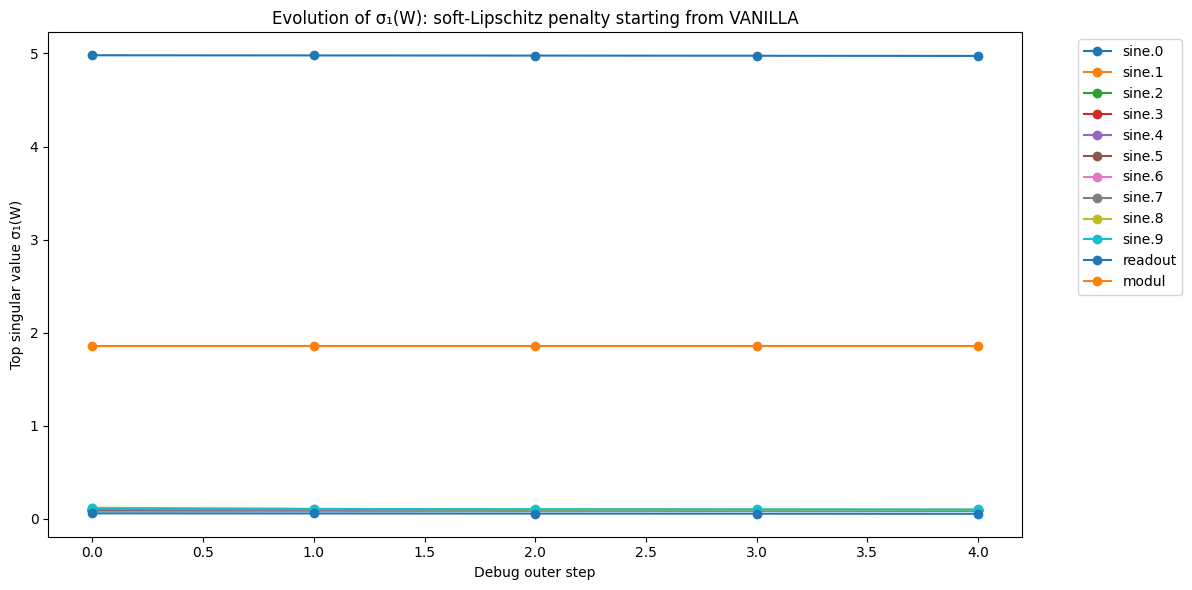

In [6]:
# ---- Debug soft-Lipschitz training: gradients, W-updates, singular-value evolution ----

import copy
from types import SimpleNamespace
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from SIREN import SineAffine
from variants.soft_lipschitz import SoftLipschitz


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def make_debug_softlip_args():
    """
    Minimal args object expected by SoftLipschitz.penalty().
    """
    return SimpleNamespace(
        soft_lip_cap=DEBUG_SOFT_LIP_CAP,
        soft_lip_lambda=DEBUG_SOFT_LIP_LAMBDA,
        soft_lip_apply_to=DEBUG_SOFT_LIP_APPLY_TO,
        soft_lip_skip_first=DEBUG_SOFT_LIP_SKIP_FIRST,
        soft_lip_power_iters=DEBUG_SOFT_LIP_POWER_ITERS,
    )


def collect_linear_layers(model):
    """
    Collect all linear W matrices we care about:
      - sine.0, sine.1, ... : SineAffine.affine layers
      - readout             : hidden2rgb
      - modul               : modulation linear layer
    """
    layers = {}

    sine_idx = 0
    for module in model.modules():
        if isinstance(module, SineAffine):
            layers[f"sine.{sine_idx}"] = module.affine
            sine_idx += 1

    if hasattr(model, "siren") and hasattr(model.siren, "hidden2rgb"):
        layers["readout"] = model.siren.hidden2rgb

    if hasattr(model, "modul"):
        layers["modul"] = model.modul

    return layers


@torch.no_grad()
def singular_values_of_linear(linear_layer):
    """
    Return all singular values of a Linear layer weight matrix.
    """
    W = linear_layer.weight.detach()
    W2d = W.reshape(W.shape[0], -1)
    return torch.linalg.svdvals(W2d).detach().cpu()


@torch.no_grad()
def topk_singular_string(svals, k=5):
    vals = svals[:k].numpy()
    return "[" + ", ".join(f"{v:.4f}" for v in vals) + "]"


def grad_norm_or_zero(param):
    if param.grad is None:
        return 0.0
    return float(param.grad.detach().norm().item())


def snapshot_weights(layers):
    """
    Save W before optimizer step.
    """
    return {
        name: layer.weight.detach().clone()
        for name, layer in layers.items()
    }


@torch.no_grad()
def update_norms(layers, before_weights):
    """
    Compute ||W_after - W_before|| for each layer.
    """
    out = {}
    for name, layer in layers.items():
        W_before = before_weights[name]
        W_after = layer.weight.detach()
        delta = W_after - W_before

        update_norm = float(delta.norm().item())
        weight_norm = float(W_before.norm().item())
        relative_update = update_norm / (weight_norm + 1e-12)

        out[name] = {
            "update_norm": update_norm,
            "relative_update": relative_update,
        }

    return out


def get_layer_grad_norms(layers):
    """
    Return gradient norm of each layer's W.
    """
    return {
        name: grad_norm_or_zero(layer.weight)
        for name, layer in layers.items()
    }


def zero_all_grads(model, optimizer=None):
    if optimizer is not None:
        optimizer.zero_grad(set_to_none=True)
    else:
        for p in model.parameters():
            p.grad = None


def compute_outer_mse_like_trainer(model, images, inner_steps, inner_lr, device):
    """
    Mimics trainer.py for a single batch:
      1. Fit a modulation phi for each image.
      2. Recompute reconstruction loss using the fitted phi.
      3. Average over the batch.
    """
    batch_size = images.size(0)

    images_flat = images.view(batch_size, 1, -1).moveaxis(1, -1).to(device)

    inner_criterion = nn.MSELoss()
    modulators = []

    # Inner loop: fit phi per image
    for batch_id in range(batch_size):
        phi = torch.zeros(model.modul_features, device=device, dtype=torch.float32)
        phi.requires_grad_(True)

        inner_optimizer = optim.SGD([phi], lr=inner_lr)

        for _ in range(inner_steps):
            inner_optimizer.zero_grad(set_to_none=True)

            fitted = model(phi)
            inner_loss = inner_criterion(fitted, images_flat[batch_id])

            inner_loss.backward()
            inner_optimizer.step()

        phi.requires_grad_(False)
        modulators.append(phi.detach())

    # Clear model gradients accumulated during inner-loop backward calls.
    for p in model.parameters():
        p.grad = None

    # Outer reconstruction loss
    outer_mse = torch.zeros((), device=device)

    for batch_id in range(batch_size):
        fitted = model(modulators[batch_id])
        outer_mse = outer_mse + inner_criterion(fitted, images_flat[batch_id]) / batch_size

    return outer_mse


def compute_grad_components(model, layers, mse_loss, penalty_loss, optimizer,
                            loss_mode="total"):
    """
    Compute gradient norms from:
      - MSE alone
      - penalty alone
      - selected training loss

    loss_mode:
      "total"        -> mse_loss + penalty_loss
      "penalty_only" -> penalty_loss
      "mse_only"     -> mse_loss
    """
    # MSE gradients
    zero_all_grads(model, optimizer)
    mse_loss.backward(retain_graph=True)
    mse_grad_norms = get_layer_grad_norms(layers)

    # Penalty gradients
    zero_all_grads(model, optimizer)
    penalty_loss.backward(retain_graph=True)
    penalty_grad_norms = get_layer_grad_norms(layers)

    # Chosen training loss
    if loss_mode == "total":
        train_loss = mse_loss + penalty_loss
    elif loss_mode == "penalty_only":
        train_loss = penalty_loss
    elif loss_mode == "mse_only":
        train_loss = mse_loss
    else:
        raise ValueError(
            "loss_mode must be 'total', 'penalty_only', or 'mse_only'"
        )

    zero_all_grads(model, optimizer)
    train_loss.backward()
    train_grad_norms = get_layer_grad_norms(layers)

    return mse_grad_norms, penalty_grad_norms, train_grad_norms, train_loss
# ---------------------------------------------------------------------
# Build temporary debug model
# ---------------------------------------------------------------------

if DEBUG_START_FROM == "vanilla":
    if vanilla is None:
        raise RuntimeError("vanilla model is missing. Load the vanilla checkpoint first.")
    debug_model = copy.deepcopy(vanilla).to(DEVICE)
    debug_name = "VANILLA"

elif DEBUG_START_FROM == "softlip":
    if softlip is None:
        raise RuntimeError("softlip model is missing. Load the soft-Lipschitz checkpoint first.")
    debug_model = copy.deepcopy(softlip).to(DEVICE)
    debug_name = "SOFT-LIPSCHITZ"

else:
    raise ValueError("DEBUG_START_FROM must be either 'vanilla' or 'softlip'.")

debug_model.train()

for p in debug_model.parameters():
    p.requires_grad_(True)

debug_args = make_debug_softlip_args()
debug_optimizer = optim.Adam(debug_model.parameters(), lr=DEBUG_OUTER_LR)

debug_loader = get_mnist_loader(
    root=str(DATA_ROOT / "data"),
    train=True,
    batch_size=DEBUG_BATCH_SIZE,
    num_workers=0,
    pin_memory=False,
)

sigma_history = defaultdict(list)

print(f"Debug soft-Lipschitz penalty starting from {debug_name}")
print(f"outer_steps={DEBUG_OUTER_STEPS}")
print(f"batch_size={DEBUG_BATCH_SIZE}")
print(f"inner_steps={DEBUG_INNER_STEPS}")
print(f"inner_lr={DEBUG_INNER_LR}")
print(f"outer_lr={DEBUG_OUTER_LR}")
print(f"soft_lip_cap={DEBUG_SOFT_LIP_CAP}")
print(f"soft_lip_lambda={DEBUG_SOFT_LIP_LAMBDA}")
print(f"soft_lip_apply_to={DEBUG_SOFT_LIP_APPLY_TO}")
print(f"soft_lip_skip_first={DEBUG_SOFT_LIP_SKIP_FIRST}")
print("-" * 100)


# ---------------------------------------------------------------------
# Run a few debug training steps
# ---------------------------------------------------------------------

for outer_step, (images, labels) in enumerate(debug_loader):
    if outer_step >= DEBUG_OUTER_STEPS:
        break

    images = images.to(DEVICE)
    layers = collect_linear_layers(debug_model)

    # Singular values before update
    svals_before = {
        name: singular_values_of_linear(layer)
        for name, layer in layers.items()
    }

    before_weights = snapshot_weights(layers)

    # Compute losses
    mse_loss = compute_outer_mse_like_trainer(
        model=debug_model,
        images=images,
        inner_steps=DEBUG_INNER_STEPS,
        inner_lr=DEBUG_INNER_LR,
        device=DEVICE,
    )

    penalty_loss = SoftLipschitz.penalty(debug_model, debug_args)

    mse_grad_norms, penalty_grad_norms, train_grad_norms, train_loss = compute_grad_components(
        model=debug_model,
        layers=layers,
        mse_loss=mse_loss,
        penalty_loss=penalty_loss,
        optimizer=debug_optimizer,
        loss_mode=DEBUG_LOSS_MODE,
    )

    # Optimizer step uses total gradients already computed above
    debug_optimizer.step()

    # Singular values after update
    svals_after = {
        name: singular_values_of_linear(layer)
        for name, layer in layers.items()
    }

    updates = update_norms(layers, before_weights)

    print(f"\nOUTER STEP {outer_step}")
    print(f"MSE loss     = {float(mse_loss.detach().cpu()):.8f}")
    print(f"Penalty loss = {float(penalty_loss.detach().cpu()):.8f}")
    print(f"Train loss   = {float(train_loss.detach().cpu()):.8f}  ({DEBUG_LOSS_MODE})")
    print("-" * 100)

    header = (
        f"{'layer':<10} "
        f"{'||g_mse||':>12} "
        f"{'||g_pen||':>12} "
        f"{'||g_train||':>12} "
        f"{'||dW||':>12} "
        f"{'rel_dW':>12} "
        f"{'sigma1 before':>15} "
        f"{'sigma1 after':>15}"
    )
    print(header)
    print("-" * len(header))

    for name, layer in layers.items():
        sigma1_before = float(svals_before[name][0])
        sigma1_after = float(svals_after[name][0])

        print(
            f"{name:<10} "
            f"{mse_grad_norms[name]:12.4e} "
            f"{penalty_grad_norms[name]:12.4e} "
            f"{train_grad_norms[name]:12.4e} "
            f"{updates[name]['update_norm']:12.4e} "
            f"{updates[name]['relative_update']:12.4e} "
            f"{sigma1_before:15.6f} "
            f"{sigma1_after:15.6f}"
        )

        sigma_history[name].append(sigma1_after)

    print("\nTop singular values before -> after:")
    for name in layers.keys():
        print(
            f"{name:<10} "
            f"{topk_singular_string(svals_before[name], DEBUG_TOPK_SINGULARS)} "
            f" -> "
            f"{topk_singular_string(svals_after[name], DEBUG_TOPK_SINGULARS)}"
        )


# ---------------------------------------------------------------------
# Plot sigma_1 evolution
# ---------------------------------------------------------------------

plt.figure(figsize=(12, 6))

for name, values in sigma_history.items():
    plt.plot(range(len(values)), values, marker="o", label=name)

plt.xlabel("Debug outer step")
plt.ylabel("Top singular value σ₁(W)")
plt.title(f"Evolution of σ₁(W): soft-Lipschitz penalty starting from {debug_name}")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Vanilla SIREN singular-value audit

sine.0
  W shape                : (256, 2)
  freq                   : 30.0
  top-10 singular values:
    [4.98244, 4.49263]
  sigma_1                : 4.982442
  freq * sigma_1         : 149.473271

sine.1
  W shape                : (256, 256)
  freq                   : 30.0
  top-10 singular values:
    [0.09266, 0.09147, 0.09103, 0.09058, 0.08952, 0.08920, 0.08722, 0.08694, 0.08621, 0.08565]
  sigma_1                : 0.092663
  freq * sigma_1         : 2.779878

sine.2
  W shape                : (256, 256)
  freq                   : 30.0
  top-10 singular values:
    [0.09486, 0.09373, 0.09295, 0.09163, 0.08996, 0.08958, 0.08852, 0.08775, 0.08709, 0.08677]
  sigma_1                : 0.094855
  freq * sigma_1         : 2.845657

sine.3
  W shape                : (256, 256)
  freq                   : 30.0
  top-10 singular values:
    [0.09300, 0.09227, 0.09130, 0.09062, 0.08976, 0.08875, 0.08777, 0.08739, 0.08613, 0.08594]
  sigma_1                

,layer,type,shape,freq,sigma_1,sigma_min,freq*sigma_1,log10(freq*sigma_1)
0,sine.0,sine affine W,"(256, 2)",30.0,4.982442,4.492634,149.473271,2.174564
1,sine.1,sine affine W,"(256, 256)",30.0,0.092663,0.000203,2.779878,0.444026
2,sine.2,sine affine W,"(256, 256)",30.0,0.094855,0.000192,2.845657,0.454182
3,sine.3,sine affine W,"(256, 256)",30.0,0.092998,0.000191,2.789927,0.445593
4,sine.4,sine affine W,"(256, 256)",30.0,0.093318,0.000114,2.799543,0.447087
5,sine.5,sine affine W,"(256, 256)",30.0,0.097486,0.000026,2.924594,0.466066
6,sine.6,sine affine W,"(256, 256)",30.0,0.105713,0.000116,3.171402,0.501251
7,sine.7,sine affine W,"(256, 256)",30.0,0.119848,0.000089,3.595430,0.555751
8,sine.8,sine affine W,"(256, 256)",30.0,0.124839,0.000043,3.745156,0.573470
9,sine.9,sine affine W,"(256, 256)",30.0,0.125309,0.000089,3.759267,0.575103



Worst-case coordinate-input amplification bound
Bound:
  Lip(x -> output) <= sigma(readout) * product_l(freq_l * sigma(W_l))

  log10 bound      : 5.4294
  bound            : 2.6880e+05

Worst-case modulation-vector amplification bound
Recursive bound:
  J_l <= freq_l * ( sigma(W_l) * J_{l-1} + sigma(M_l) )
  Lip(phi -> output) <= sigma(readout) * J_L

  log10 bound      : 4.9185
  bound            : 8.2889e+04


,layer,sigma_W,freq*sigma_W,sigma_M_chunk,J_phi_bound_after_layer,log10_J_phi_bound
0,sine.0,4.982442,149.473271,0.988783,2.966348e+01,1.472222
1,sine.1,0.092663,2.779878,0.985495,1.120257e+02,2.049318
2,sine.2,0.094855,2.845657,0.989417,3.484692e+02,2.542164
3,sine.3,0.092998,2.789927,0.981468,1.001647e+03,3.000715
4,sine.4,0.093318,2.799543,0.978957,2.833524e+03,3.452327
5,sine.5,0.097486,2.924594,0.973231,8.316104e+03,3.919920
6,sine.6,0.105713,3.171402,0.985218,2.640327e+04,4.421658
7,sine.7,0.119848,3.595430,0.974229,9.496032e+04,4.977542
8,sine.8,0.124839,3.745156,0.977082,3.556706e+05,5.551048
9,sine.9,0.125309,3.759267,0.976432,1.337090e+06,6.126161


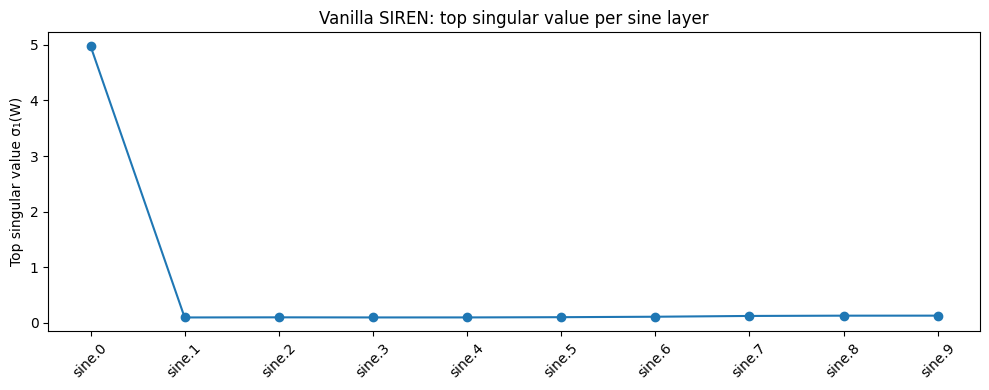

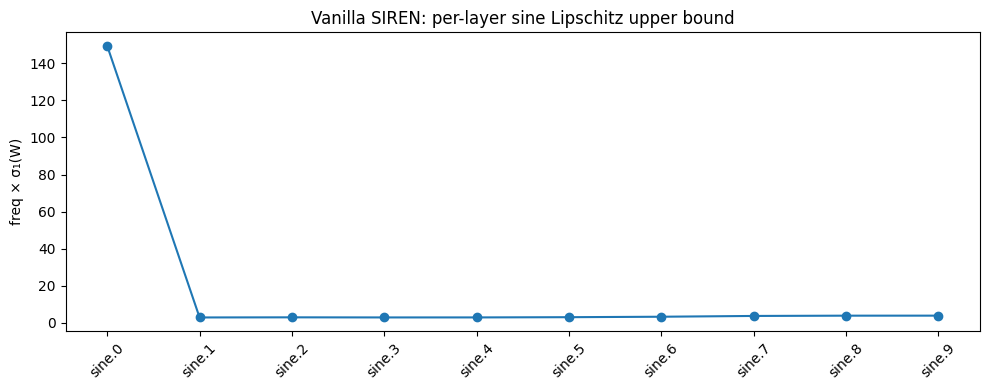

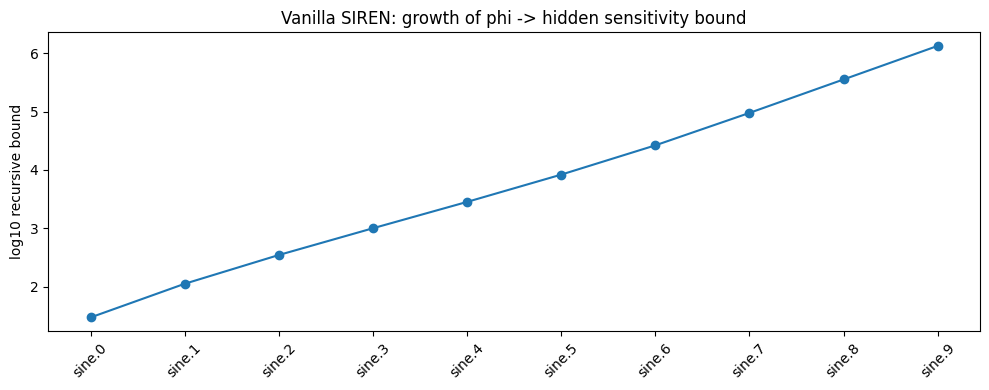

In [7]:
# ---- Vanilla SIREN singular values + Lipschitz-style amplification bounds ----

import math
import pandas as pd
import torch
import matplotlib.pyplot as plt

from SIREN import SineAffine


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

VANILLA_TOPK_SINGULARS = 10
PRINT_FULL_SINGULAR_VALUES = False   # set True if you want all singular values per layer


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

@torch.no_grad()
def svdvals_tensor(W):
    """
    Compute all singular values of a weight matrix.
    """
    W = W.detach().float().cpu()
    W2d = W.reshape(W.shape[0], -1)
    return torch.linalg.svdvals(W2d)


def fmt_bound_from_log10(log10_value):
    """
    Pretty-print very large Lipschitz products safely.
    """
    if not np.isfinite(log10_value):
        return "nan/inf"
    if log10_value < 300:
        return f"{10 ** log10_value:.4e}"
    return f"1e{log10_value:.2f}"


def collect_vanilla_siren_layers(model):
    """
    Collect:
      - sine.0, sine.1, ... = SineAffine.affine layers
      - readout = final hidden2rgb layer
      - modul = phi -> shift linear layer
    """
    sine_layers = []
    sine_idx = 0

    for module in model.modules():
        if isinstance(module, SineAffine):
            sine_layers.append((f"sine.{sine_idx}", module))
            sine_idx += 1

    readout = model.siren.hidden2rgb if hasattr(model, "siren") else None
    modul = model.modul if hasattr(model, "modul") else None

    return sine_layers, readout, modul


def topk_string(svals, k=10):
    vals = svals[:k].numpy()
    return "[" + ", ".join(f"{v:.5f}" for v in vals) + "]"


def full_string(svals):
    vals = svals.numpy()
    return "[" + ", ".join(f"{v:.5f}" for v in vals) + "]"


# ---------------------------------------------------------------------
# Main analysis
# ---------------------------------------------------------------------

if vanilla is None:
    raise RuntimeError("vanilla model is missing. Load the vanilla checkpoint first.")

vanilla_model = vanilla.to(DEVICE).eval()
sine_layers, readout, modul = collect_vanilla_siren_layers(vanilla_model)

rows = []

print("=" * 120)
print("Vanilla SIREN singular-value audit")
print("=" * 120)

# ---- Sine layers -----------------------------------------------------

for name, layer in sine_layers:
    W = layer.affine.weight
    svals = svdvals_tensor(W)

    sigma1 = float(svals[0])
    sigma_min = float(svals[-1])
    freq = float(layer.freq)
    effective_lip = freq * sigma1

    rows.append({
        "layer": name,
        "type": "sine affine W",
        "shape": tuple(W.shape),
        "freq": freq,
        "sigma_1": sigma1,
        "sigma_min": sigma_min,
        "freq*sigma_1": effective_lip,
        "log10(freq*sigma_1)": math.log10(max(effective_lip, 1e-300)),
    })

    print(f"\n{name}")
    print(f"  W shape                : {tuple(W.shape)}")
    print(f"  freq                   : {freq}")
    print(f"  top-{VANILLA_TOPK_SINGULARS} singular values:")
    print(f"    {topk_string(svals, VANILLA_TOPK_SINGULARS)}")
    print(f"  sigma_1                : {sigma1:.6f}")
    print(f"  freq * sigma_1         : {effective_lip:.6f}")

    if PRINT_FULL_SINGULAR_VALUES:
        print("  full singular values:")
        print(f"    {full_string(svals)}")


# ---- Readout layer ---------------------------------------------------

if readout is not None:
    W = readout.weight
    svals_readout = svdvals_tensor(W)

    sigma_readout = float(svals_readout[0])

    rows.append({
        "layer": "readout",
        "type": "linear readout",
        "shape": tuple(W.shape),
        "freq": None,
        "sigma_1": sigma_readout,
        "sigma_min": float(svals_readout[-1]),
        "freq*sigma_1": sigma_readout,
        "log10(freq*sigma_1)": math.log10(max(sigma_readout, 1e-300)),
    })

    print("\nreadout")
    print(f"  W shape                : {tuple(W.shape)}")
    print(f"  singular values        : {topk_string(svals_readout, VANILLA_TOPK_SINGULARS)}")
    print(f"  sigma_1                : {sigma_readout:.6f}")


# ---- Modulation layer ------------------------------------------------

if modul is not None:
    W = modul.weight
    svals_modul = svdvals_tensor(W)

    sigma_modul = float(svals_modul[0])

    rows.append({
        "layer": "modul",
        "type": "phi -> all shifts",
        "shape": tuple(W.shape),
        "freq": None,
        "sigma_1": sigma_modul,
        "sigma_min": float(svals_modul[-1]),
        "freq*sigma_1": None,
        "log10(freq*sigma_1)": None,
    })

    print("\nmodul")
    print(f"  W shape                : {tuple(W.shape)}")
    print(f"  top-{VANILLA_TOPK_SINGULARS} singular values:")
    print(f"    {topk_string(svals_modul, VANILLA_TOPK_SINGULARS)}")
    print(f"  sigma_1                : {sigma_modul:.6f}")

    if PRINT_FULL_SINGULAR_VALUES:
        print("  full singular values:")
        print(f"    {full_string(svals_modul)}")


# ---------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------

df_svals = pd.DataFrame(rows)

print("\n" + "=" * 120)
print("Summary table")
print("=" * 120)

display(df_svals)


# ---------------------------------------------------------------------
# Coordinate-input Lipschitz upper bound
# ---------------------------------------------------------------------
# For the mapping coordinates x -> reconstructed intensity:
#
# h_l = sin(freq_l * (W_l h_{l-1} + b_l + shift_l))
#
# Since |sin'(.)| <= 1, each sine layer has upper bound:
#
#   Lip_l <= freq_l * sigma_1(W_l)
#
# The final readout contributes sigma_1(readout).
#
# Therefore:
#
#   Lip_coord_to_output <= sigma_readout * Π_l freq_l * sigma_1(W_l)
#
# This is a worst-case upper bound, not the actual local Lipschitz value.

coord_log10_terms = []

for name, layer in sine_layers:
    sigma1 = float(svdvals_tensor(layer.affine.weight)[0])
    freq = float(layer.freq)
    term = freq * sigma1
    coord_log10_terms.append(math.log10(max(term, 1e-300)))

sigma_readout = float(svdvals_tensor(readout.weight)[0]) if readout is not None else 1.0
coord_log10_terms.append(math.log10(max(sigma_readout, 1e-300)))

coord_bound_log10 = sum(coord_log10_terms)

print("\n" + "=" * 120)
print("Worst-case coordinate-input amplification bound")
print("=" * 120)
print("Bound:")
print("  Lip(x -> output) <= sigma(readout) * product_l(freq_l * sigma(W_l))")
print()
print(f"  log10 bound      : {coord_bound_log10:.4f}")
print(f"  bound            : {fmt_bound_from_log10(coord_bound_log10)}")


# ---------------------------------------------------------------------
# Modulation-vector Lipschitz upper bound
# ---------------------------------------------------------------------
# This estimates how much changing phi can affect the reconstructed output.
#
# The modulation layer maps phi -> all shifts.
# Each sine layer receives one shift chunk:
#
#   shift_l(phi) = M_l phi
#
# A recursive upper bound for sensitivity to phi is:
#
#   J_0 = 0
#   J_l <= freq_l * ( sigma(W_l) * J_{l-1} + sigma(M_l) )
#
# Then:
#
#   Lip(phi -> output) <= sigma(readout) * J_L
#
# This is more relevant for the classifier input space because the classifier
# receives phi vectors.

hidden = vanilla_model.siren.hidden_features
moddim = vanilla_model.modul_features

J_bound = 0.0
phi_rows = []

for i, (name, layer) in enumerate(sine_layers):
    sigma_W = float(svdvals_tensor(layer.affine.weight)[0])
    freq = float(layer.freq)

    # Modulation chunk for this layer: hidden_features x mod_dim
    M_i = vanilla_model.modul.weight[
        i * hidden : (i + 1) * hidden,
        :
    ]

    sigma_M = float(svdvals_tensor(M_i)[0])

    J_prev = J_bound
    J_bound = freq * (sigma_W * J_prev + sigma_M)

    phi_rows.append({
        "layer": name,
        "sigma_W": sigma_W,
        "freq*sigma_W": freq * sigma_W,
        "sigma_M_chunk": sigma_M,
        "J_phi_bound_after_layer": J_bound,
        "log10_J_phi_bound": math.log10(max(J_bound, 1e-300)),
    })

phi_output_bound = sigma_readout * J_bound
phi_output_bound_log10 = math.log10(max(phi_output_bound, 1e-300))

df_phi_bound = pd.DataFrame(phi_rows)

print("\n" + "=" * 120)
print("Worst-case modulation-vector amplification bound")
print("=" * 120)
print("Recursive bound:")
print("  J_l <= freq_l * ( sigma(W_l) * J_{l-1} + sigma(M_l) )")
print("  Lip(phi -> output) <= sigma(readout) * J_L")
print()
print(f"  log10 bound      : {phi_output_bound_log10:.4f}")
print(f"  bound            : {fmt_bound_from_log10(phi_output_bound_log10)}")

display(df_phi_bound)


# ---------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------

# Plot top singular values of sine layers
sine_names = [row["layer"] for row in rows if row["type"] == "sine affine W"]
sine_sigma1 = [row["sigma_1"] for row in rows if row["type"] == "sine affine W"]
sine_eff_lip = [row["freq*sigma_1"] for row in rows if row["type"] == "sine affine W"]

plt.figure(figsize=(10, 4))
plt.plot(sine_names, sine_sigma1, marker="o")
plt.xticks(rotation=45)
plt.ylabel("Top singular value σ₁(W)")
plt.title("Vanilla SIREN: top singular value per sine layer")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(sine_names, sine_eff_lip, marker="o")
plt.xticks(rotation=45)
plt.ylabel("freq × σ₁(W)")
plt.title("Vanilla SIREN: per-layer sine Lipschitz upper bound")
plt.tight_layout()
plt.show()

# Plot recursive phi amplification
plt.figure(figsize=(10, 4))
plt.plot(
    [row["layer"] for row in phi_rows],
    [row["log10_J_phi_bound"] for row in phi_rows],
    marker="o",
)
plt.xticks(rotation=45)
plt.ylabel("log10 recursive bound")
plt.title("Vanilla SIREN: growth of phi -> hidden sensitivity bound")
plt.tight_layout()
plt.show()

Empirical vanilla perturbation amplification


,eps,eps_255,mean_dx_l2,mean_dx_linf,mean_dphi_l2,mean_phi_amp_l2,median_phi_amp_l2,mean_mse_clean,mean_mse_pert,mean_dlogits_l2,mean_logit_amp_from_phi,mean_logit_amp_from_x,clean_acc,pert_acc,changed_pred_rate
0,0.003922,1.0,0.084178,0.003922,0.000315,0.003727,0.003401,0.026935,0.026784,0.093705,313.062347,1.124389,1.0,1.0,0.0
1,0.007843,2.0,0.167209,0.007843,0.000677,0.004039,0.003425,0.026935,0.026636,0.191163,301.911835,1.153821,1.0,1.0,0.0
2,0.015686,4.0,0.330648,0.015686,0.001279,0.003866,0.003403,0.026935,0.026306,0.362906,301.529938,1.105363,1.0,1.0,0.0
3,0.031373,8.0,0.653875,0.031373,0.002324,0.003552,0.003358,0.026935,0.025789,0.767270,334.273987,1.182296,1.0,1.0,0.0
4,0.062745,16.0,1.300049,0.062745,0.005102,0.003924,0.003502,0.026935,0.025272,1.650272,337.520996,1.276260,1.0,1.0,0.0


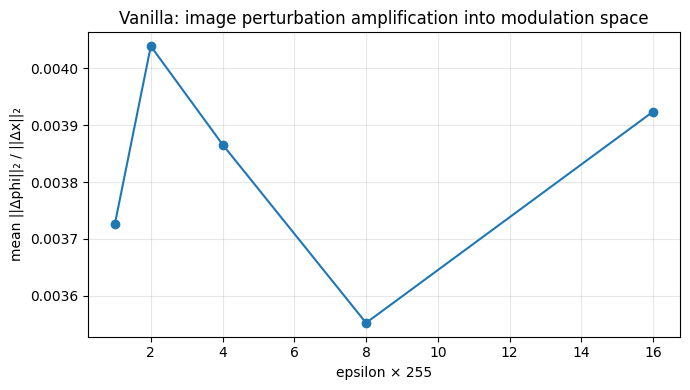

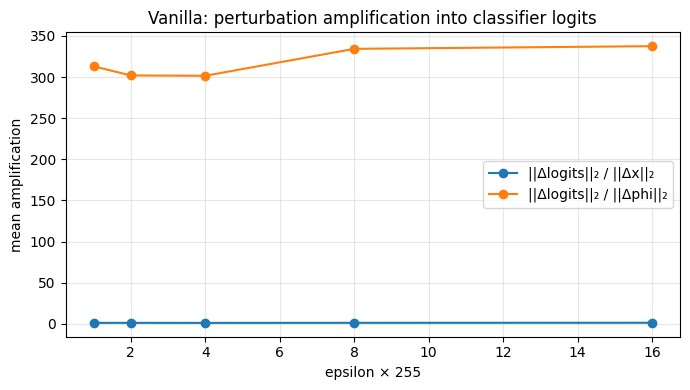

In [8]:
# ---- Empirical vanilla perturbation amplification: image -> modulation -> classifier ----

import pandas as pd
import torch
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

AMP_EPS_LIST = [1/255, 2/255, 4/255, 8/255, 16/255]
AMP_N_IMAGES = 32
AMP_FIT_STEPS = 5        # match makeset.py default for MNIST vanilla
AMP_FIT_LR = FIT_LR
AMP_NOISE_MODE = "sign"  # "sign" or "uniform"


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def make_random_perturbation(x, eps, mode="sign"):
    """
    Create random perturbation with ||delta||_inf <= eps.
    x shape: (B, 28, 28)
    """
    if mode == "sign":
        delta = eps * torch.sign(torch.randn_like(x))
    elif mode == "uniform":
        delta = torch.empty_like(x).uniform_(-eps, eps)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    x_pert = torch.clamp(x + delta, 0.0, 1.0)
    actual_delta = x_pert - x
    return x_pert, actual_delta


@torch.no_grad()
def l2_per_sample(tensor):
    return tensor.reshape(tensor.shape[0], -1).norm(dim=1)


def empirical_amplification_for_eps(model, classifier, images, labels, eps,
                                    fit_steps=5, fit_lr=0.01,
                                    noise_mode="sign", device=DEVICE):
    """
    For a batch of images:
      1. perturb images by eps
      2. fit phi_clean and phi_pert
      3. measure amplification image -> phi
      4. optionally measure amplification phi -> logits if classifier exists
    """
    model = model.to(device).eval()
    images = images.to(device)
    labels = labels.to(device)

    x_pert, delta_x = make_random_perturbation(images, eps, mode=noise_mode)

    x_flat = images.reshape(images.shape[0], -1)
    x_pert_flat = x_pert.reshape(x_pert.shape[0], -1)

    # Fit modulation vectors for clean and perturbed images
    phi_clean, mse_clean = batched_fit_phi(
        model,
        x_flat,
        steps=fit_steps,
        lr=fit_lr,
        device=device,
    )

    phi_pert, mse_pert = batched_fit_phi(
        model,
        x_pert_flat,
        steps=fit_steps,
        lr=fit_lr,
        device=device,
    )

    delta_phi = phi_pert - phi_clean

    # Norms
    dx_l2 = l2_per_sample(delta_x)
    dx_linf = delta_x.reshape(delta_x.shape[0], -1).abs().max(dim=1).values

    dphi_l2 = l2_per_sample(delta_phi)

    phi_amp_l2 = dphi_l2 / (dx_l2 + 1e-12)

    result = {
        "eps": eps,
        "eps_255": eps * 255,
        "mean_dx_l2": float(dx_l2.mean().item()),
        "mean_dx_linf": float(dx_linf.mean().item()),
        "mean_dphi_l2": float(dphi_l2.mean().item()),
        "mean_phi_amp_l2": float(phi_amp_l2.mean().item()),
        "median_phi_amp_l2": float(phi_amp_l2.median().item()),
        "mean_mse_clean": float(mse_clean.mean().item()),
        "mean_mse_pert": float(mse_pert.mean().item()),
    }

    # Optional classifier/logit amplification
    if classifier is not None:
        classifier = classifier.to(device).eval()

        with torch.no_grad():
            logits_clean = classifier(phi_clean)
            logits_pert = classifier(phi_pert)

            delta_logits = logits_pert - logits_clean
            dlogits_l2 = l2_per_sample(delta_logits)

            logit_amp_from_phi = dlogits_l2 / (dphi_l2 + 1e-12)
            logit_amp_from_x = dlogits_l2 / (dx_l2 + 1e-12)

            pred_clean = logits_clean.argmax(dim=1)
            pred_pert = logits_pert.argmax(dim=1)

            clean_acc = (pred_clean == labels).float().mean()
            pert_acc = (pred_pert == labels).float().mean()
            changed_pred = (pred_clean != pred_pert).float().mean()

        result.update({
            "mean_dlogits_l2": float(dlogits_l2.mean().item()),
            "mean_logit_amp_from_phi": float(logit_amp_from_phi.mean().item()),
            "mean_logit_amp_from_x": float(logit_amp_from_x.mean().item()),
            "clean_acc": float(clean_acc.item()),
            "pert_acc": float(pert_acc.item()),
            "changed_pred_rate": float(changed_pred.item()),
        })

    return result


# ---------------------------------------------------------------------
# Run experiment
# ---------------------------------------------------------------------

if vanilla is None:
    raise RuntimeError("vanilla model is missing.")

images_amp = mnist_images[:AMP_N_IMAGES].to(DEVICE)
labels_amp = mnist_labels[:AMP_N_IMAGES].to(DEVICE)

amp_rows = []

for eps in AMP_EPS_LIST:
    row = empirical_amplification_for_eps(
        model=vanilla,
        classifier=vanilla_clf,
        images=images_amp,
        labels=labels_amp,
        eps=eps,
        fit_steps=AMP_FIT_STEPS,
        fit_lr=AMP_FIT_LR,
        noise_mode=AMP_NOISE_MODE,
        device=DEVICE,
    )
    amp_rows.append(row)

df_amp_vanilla = pd.DataFrame(amp_rows)

print("Empirical vanilla perturbation amplification")
display(df_amp_vanilla)


# ---------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(
    df_amp_vanilla["eps_255"],
    df_amp_vanilla["mean_phi_amp_l2"],
    marker="o",
)
plt.xlabel("epsilon × 255")
plt.ylabel("mean ||Δphi||₂ / ||Δx||₂")
plt.title("Vanilla: image perturbation amplification into modulation space")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


if "mean_logit_amp_from_x" in df_amp_vanilla.columns:
    plt.figure(figsize=(7, 4))
    plt.plot(
        df_amp_vanilla["eps_255"],
        df_amp_vanilla["mean_logit_amp_from_x"],
        marker="o",
        label="||Δlogits||₂ / ||Δx||₂",
    )
    plt.plot(
        df_amp_vanilla["eps_255"],
        df_amp_vanilla["mean_logit_amp_from_phi"],
        marker="o",
        label="||Δlogits||₂ / ||Δphi||₂",
    )
    plt.xlabel("epsilon × 255")
    plt.ylabel("mean amplification")
    plt.title("Vanilla: perturbation amplification into classifier logits")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("vanilla_clf is missing, so classifier/logit amplification was skipped.")

Vanilla A(x, δ) summary


,eps,eps_255,mean_A,median_A,std_A,min_A,max_A,mean_||delta||_2,mean_||delta||_inf,mean_||delta_phi||_2,mean_mse_clean,mean_mse_pert
0,0.003922,1.0,0.004240,0.003547,0.001872,0.002948,0.009973,0.083740,0.003922,0.000356,0.026935,0.026816
1,0.007843,2.0,0.004014,0.003477,0.001571,0.002935,0.009654,0.167192,0.007843,0.000670,0.026935,0.026680
2,0.015686,4.0,0.003837,0.003423,0.001492,0.003010,0.010833,0.331037,0.015686,0.001272,0.026935,0.026276
3,0.031373,8.0,0.004092,0.003466,0.002103,0.003098,0.014898,0.655222,0.031373,0.002689,0.026935,0.025727
4,0.062745,16.0,0.003734,0.003416,0.001211,0.002944,0.008231,1.301848,0.062745,0.004868,0.026935,0.025283


Vanilla A(x, δ) per-image values


,eps,eps_255,image_index,A,||delta||_2,||delta||_inf,||delta_phi||_2,mse_clean,mse_pert
0,0.003922,1.0,0,0.002948,0.082446,0.003922,0.000243,0.026076,0.025908
1,0.003922,1.0,1,0.003378,0.085917,0.003922,0.000290,0.040328,0.040127
2,0.003922,1.0,2,0.003849,0.080368,0.003922,0.000309,0.006600,0.006574
3,0.003922,1.0,3,0.003030,0.086275,0.003922,0.000261,0.035332,0.035268
4,0.003922,1.0,4,0.009722,0.082726,0.003922,0.000804,0.024909,0.024732
5,0.003922,1.0,5,0.003335,0.082726,0.003922,0.000276,0.007946,0.007886
6,0.003922,1.0,6,0.003547,0.084655,0.003922,0.000300,0.022124,0.022039
7,0.003922,1.0,7,0.003811,0.084746,0.003922,0.000323,0.026476,0.026321
8,0.003922,1.0,8,0.007789,0.086364,0.003922,0.000673,0.037949,0.037913
9,0.003922,1.0,9,0.009973,0.085379,0.003922,0.000852,0.034140,0.034207


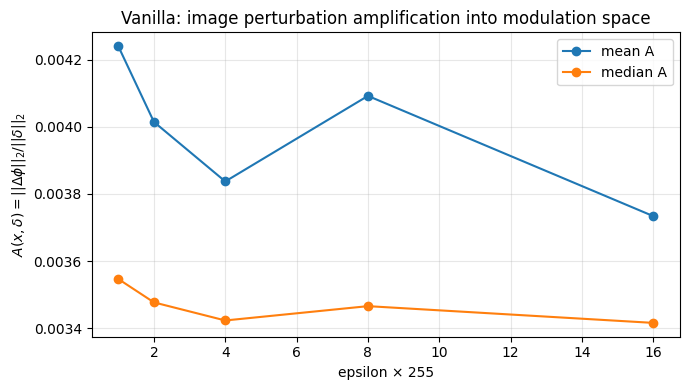

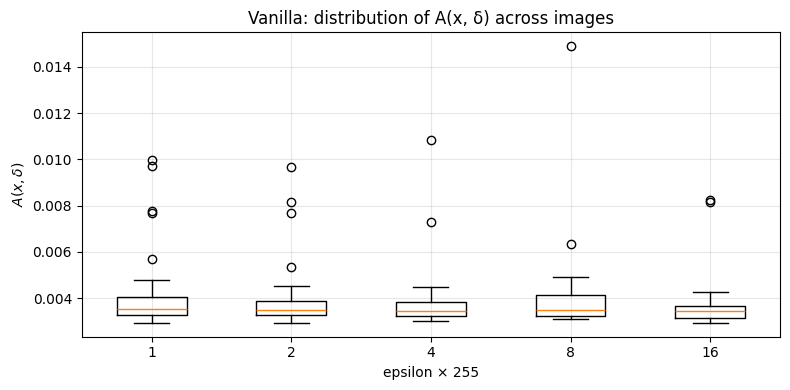

In [9]:
# ---- A(x, δ): vanilla image perturbation -> modulation-vector movement ----

import torch
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

A_EPS_LIST = [1/255, 2/255, 4/255, 8/255, 16/255]
A_N_IMAGES = 32
A_FIT_STEPS = 5
A_FIT_LR = FIT_LR
A_NOISE_MODE = "sign"   # "sign" or "uniform"
A_RANDOM_SEED = SEED


# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def make_random_delta(x, eps, mode="sign"):
    """
    Create image perturbation delta with ||delta||_inf <= eps.

    Args:
        x: image tensor of shape (B, 28, 28)
        eps: perturbation budget
        mode:
            "sign"    -> delta = eps * sign(random noise)
            "uniform" -> delta sampled uniformly from [-eps, eps]

    Returns:
        x_pert: perturbed image clipped to [0, 1]
        delta_actual: actual perturbation after clipping
    """
    if mode == "sign":
        delta = eps * torch.sign(torch.randn_like(x))
    elif mode == "uniform":
        delta = torch.empty_like(x).uniform_(-eps, eps)
    else:
        raise ValueError(f"Unknown A_NOISE_MODE: {mode}")

    x_pert = torch.clamp(x + delta, 0.0, 1.0)
    delta_actual = x_pert - x

    return x_pert, delta_actual


@torch.no_grad()
def l2_norm_per_sample(t):
    """
    Compute L2 norm for each sample in a batch.
    """
    return t.reshape(t.shape[0], -1).norm(dim=1)


def compute_A_for_eps(model, images, eps, fit_steps=5, fit_lr=0.01,
                      noise_mode="sign", device=DEVICE):
    """
    Compute A(x, delta) = ||phi(x + delta) - phi(x)||_2 / ||delta||_2
    for one epsilon value.
    """
    model = model.to(device).eval()
    images = images.to(device)

    # 1. Create perturbed images
    x_pert, delta = make_random_delta(images, eps, mode=noise_mode)

    # 2. Flatten images for batched_fit_phi
    x_flat = images.reshape(images.shape[0], -1)
    x_pert_flat = x_pert.reshape(x_pert.shape[0], -1)

    # 3. Fit modulation vectors
    phi_clean, mse_clean = batched_fit_phi(
        model,
        x_flat,
        steps=fit_steps,
        lr=fit_lr,
        device=device,
    )

    phi_pert, mse_pert = batched_fit_phi(
        model,
        x_pert_flat,
        steps=fit_steps,
        lr=fit_lr,
        device=device,
    )

    # 4. Compute A(x, delta)
    delta_phi = phi_pert - phi_clean

    delta_l2 = l2_norm_per_sample(delta)
    delta_phi_l2 = l2_norm_per_sample(delta_phi)

    A_values = delta_phi_l2 / (delta_l2 + 1e-12)

    # Also useful diagnostics
    delta_linf = delta.reshape(delta.shape[0], -1).abs().max(dim=1).values

    return {
        "eps": eps,
        "eps_255": eps * 255,
        "A_values": A_values.detach().cpu(),
        "delta_l2": delta_l2.detach().cpu(),
        "delta_linf": delta_linf.detach().cpu(),
        "delta_phi_l2": delta_phi_l2.detach().cpu(),
        "mse_clean": mse_clean.detach().cpu(),
        "mse_pert": mse_pert.detach().cpu(),
    }


# ---------------------------------------------------------------------
# Run vanilla A(x, δ) experiment
# ---------------------------------------------------------------------

if vanilla is None:
    raise RuntimeError("vanilla model is missing. Load the vanilla checkpoint first.")

torch.manual_seed(A_RANDOM_SEED)

images_A = mnist_images[:A_N_IMAGES].to(DEVICE)

A_rows = []
A_per_image_rows = []

for eps in A_EPS_LIST:
    result = compute_A_for_eps(
        model=vanilla,
        images=images_A,
        eps=eps,
        fit_steps=A_FIT_STEPS,
        fit_lr=A_FIT_LR,
        noise_mode=A_NOISE_MODE,
        device=DEVICE,
    )

    A_values = result["A_values"]

    # Summary row
    A_rows.append({
        "eps": result["eps"],
        "eps_255": result["eps_255"],
        "mean_A": float(A_values.mean().item()),
        "median_A": float(A_values.median().item()),
        "std_A": float(A_values.std().item()),
        "min_A": float(A_values.min().item()),
        "max_A": float(A_values.max().item()),
        "mean_||delta||_2": float(result["delta_l2"].mean().item()),
        "mean_||delta||_inf": float(result["delta_linf"].mean().item()),
        "mean_||delta_phi||_2": float(result["delta_phi_l2"].mean().item()),
        "mean_mse_clean": float(result["mse_clean"].mean().item()),
        "mean_mse_pert": float(result["mse_pert"].mean().item()),
    })

    # Per-image rows
    for i in range(len(A_values)):
        A_per_image_rows.append({
            "eps": result["eps"],
            "eps_255": result["eps_255"],
            "image_index": i,
            "A": float(result["A_values"][i].item()),
            "||delta||_2": float(result["delta_l2"][i].item()),
            "||delta||_inf": float(result["delta_linf"][i].item()),
            "||delta_phi||_2": float(result["delta_phi_l2"][i].item()),
            "mse_clean": float(result["mse_clean"][i].item()),
            "mse_pert": float(result["mse_pert"][i].item()),
        })

df_A_vanilla = pd.DataFrame(A_rows)
df_A_vanilla_per_image = pd.DataFrame(A_per_image_rows)

print("Vanilla A(x, δ) summary")
display(df_A_vanilla)

print("Vanilla A(x, δ) per-image values")
display(df_A_vanilla_per_image.head(20))


# ---------------------------------------------------------------------
# Plot summary
# ---------------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(
    df_A_vanilla["eps_255"],
    df_A_vanilla["mean_A"],
    marker="o",
    label="mean A",
)
plt.plot(
    df_A_vanilla["eps_255"],
    df_A_vanilla["median_A"],
    marker="o",
    label="median A",
)

plt.xlabel("epsilon × 255")
plt.ylabel(r"$A(x,\delta)=||\Delta\phi||_2 / ||\delta||_2$")
plt.title("Vanilla: image perturbation amplification into modulation space")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Boxplot: distribution across images
# ---------------------------------------------------------------------

plt.figure(figsize=(8, 4))

box_data = [
    df_A_vanilla_per_image[df_A_vanilla_per_image["eps_255"] == eps255]["A"].values
    for eps255 in df_A_vanilla["eps_255"]
]

plt.boxplot(
    box_data,
    labels=[str(int(eps255)) for eps255 in df_A_vanilla["eps_255"]],
)

plt.xlabel("epsilon × 255")
plt.ylabel(r"$A(x,\delta)$")
plt.title("Vanilla: distribution of A(x, δ) across images")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Running A(x, δ) with fit_steps=5



Running A(x, δ) with fit_steps=20

Running A(x, δ) with fit_steps=50

Running A(x, δ) with fit_steps=100

Running A(x, δ) with fit_steps=200
Vanilla A(x, δ) across inner-loop budgets


,fit_steps,eps,eps_255,mean_A,median_A,std_A,min_A,max_A,mean_||delta||_2,mean_||delta_phi||_2,mean_mse_clean,mean_mse_pert
0,5,0.003922,1.0,0.004240,0.003547,0.001872,0.002948,0.009973,0.083740,0.000356,0.026935,0.026816
1,5,0.007843,2.0,0.004014,0.003477,0.001571,0.002935,0.009654,0.167192,0.000670,0.026935,0.026680
2,5,0.015686,4.0,0.003837,0.003423,0.001492,0.003010,0.010833,0.331037,0.001272,0.026935,0.026276
3,5,0.031373,8.0,0.004092,0.003466,0.002103,0.003098,0.014898,0.655222,0.002689,0.026935,0.025727
4,5,0.062745,16.0,0.003734,0.003416,0.001211,0.002944,0.008231,1.301848,0.004868,0.026935,0.025283
5,20,0.003922,1.0,0.009095,0.007073,0.008407,0.005860,0.052225,0.083740,0.000763,0.021099,0.021002
6,20,0.007843,2.0,0.009009,0.007106,0.006686,0.005799,0.037058,0.167192,0.001499,0.021099,0.020899
7,20,0.015686,4.0,0.009675,0.007154,0.007045,0.006183,0.033809,0.331037,0.003216,0.021099,0.020634
8,20,0.031373,8.0,0.008401,0.007212,0.004371,0.006468,0.027896,0.655222,0.005524,0.021099,0.020161
9,20,0.062745,16.0,0.008256,0.007331,0.002215,0.006169,0.015150,1.301848,0.010744,0.021099,0.019876


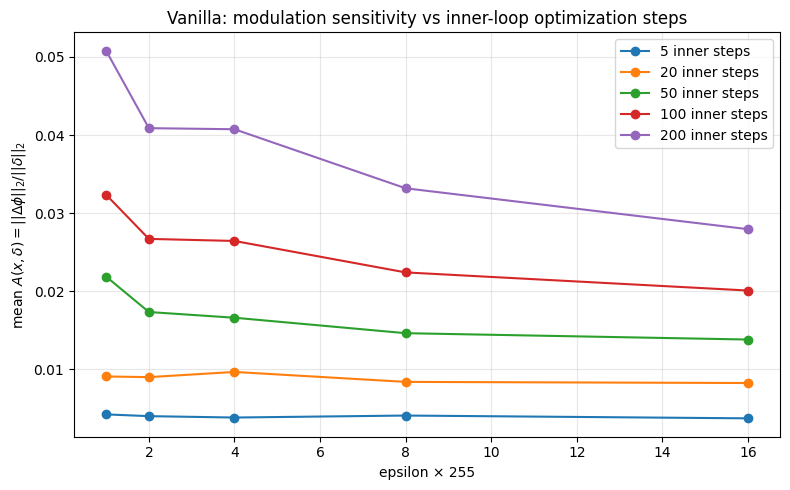

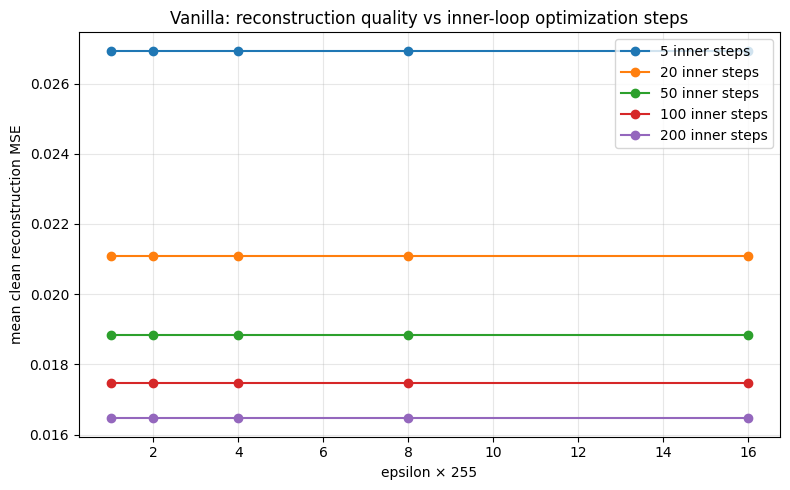

In [10]:
# ---- Vanilla A(x, δ) across different inner-loop budgets ----

A_FIT_STEPS_LIST = [5, 20, 50, 100, 200]
A_EPS_LIST = [1/255, 2/255, 4/255, 8/255, 16/255]
A_N_IMAGES = 32
A_FIT_LR = FIT_LR
A_NOISE_MODE = "sign"
A_RANDOM_SEED = SEED

all_rows = []

if vanilla is None:
    raise RuntimeError("vanilla model is missing. Load the vanilla checkpoint first.")

images_A = mnist_images[:A_N_IMAGES].to(DEVICE)

for fit_steps in A_FIT_STEPS_LIST:
    print(f"\nRunning A(x, δ) with fit_steps={fit_steps}")

    torch.manual_seed(A_RANDOM_SEED)

    for eps in A_EPS_LIST:
        result = compute_A_for_eps(
            model=vanilla,
            images=images_A,
            eps=eps,
            fit_steps=fit_steps,
            fit_lr=A_FIT_LR,
            noise_mode=A_NOISE_MODE,
            device=DEVICE,
        )

        A_values = result["A_values"]

        all_rows.append({
            "fit_steps": fit_steps,
            "eps": result["eps"],
            "eps_255": result["eps_255"],
            "mean_A": float(A_values.mean().item()),
            "median_A": float(A_values.median().item()),
            "std_A": float(A_values.std().item()),
            "min_A": float(A_values.min().item()),
            "max_A": float(A_values.max().item()),
            "mean_||delta||_2": float(result["delta_l2"].mean().item()),
            "mean_||delta_phi||_2": float(result["delta_phi_l2"].mean().item()),
            "mean_mse_clean": float(result["mse_clean"].mean().item()),
            "mean_mse_pert": float(result["mse_pert"].mean().item()),
        })

df_A_vanilla_steps = pd.DataFrame(all_rows)

print("Vanilla A(x, δ) across inner-loop budgets")
display(df_A_vanilla_steps)

plt.figure(figsize=(8, 5))

for fit_steps in A_FIT_STEPS_LIST:
    df_sub = df_A_vanilla_steps[df_A_vanilla_steps["fit_steps"] == fit_steps]
    plt.plot(
        df_sub["eps_255"],
        df_sub["mean_A"],
        marker="o",
        label=f"{fit_steps} inner steps",
    )

plt.xlabel("epsilon × 255")
plt.ylabel(r"mean $A(x,\delta)=||\Delta\phi||_2 / ||\delta||_2$")
plt.title("Vanilla: modulation sensitivity vs inner-loop optimization steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

for fit_steps in A_FIT_STEPS_LIST:
    df_sub = df_A_vanilla_steps[df_A_vanilla_steps["fit_steps"] == fit_steps]
    plt.plot(
        df_sub["eps_255"],
        df_sub["mean_mse_clean"],
        marker="o",
        label=f"{fit_steps} inner steps",
    )

plt.xlabel("epsilon × 255")
plt.ylabel("mean clean reconstruction MSE")
plt.title("Vanilla: reconstruction quality vs inner-loop optimization steps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Running vanilla: fit_steps=5



Running vanilla: fit_steps=20

Running vanilla: fit_steps=50

Running vanilla: fit_steps=100

Running vanilla: fit_steps=200

Running softlip: fit_steps=5

Running softlip: fit_steps=20

Running softlip: fit_steps=50

Running softlip: fit_steps=100

Running softlip: fit_steps=200
A(x, δ) comparison: vanilla vs soft-Lipschitz


,model,fit_steps,eps,eps_255,mean_A,median_A,std_A,min_A,max_A,mean_||delta||_2,mean_||delta_phi||_2,mean_mse_clean,mean_mse_pert
0,vanilla,5,0.003922,1.0,0.004240,0.003547,0.001872,0.002948,0.009973,0.083740,0.000356,0.026935,0.026816
1,vanilla,5,0.007843,2.0,0.004014,0.003477,0.001571,0.002935,0.009654,0.167192,0.000670,0.026935,0.026680
2,vanilla,5,0.015686,4.0,0.003837,0.003423,0.001492,0.003010,0.010833,0.331037,0.001272,0.026935,0.026276
3,vanilla,5,0.031373,8.0,0.004092,0.003466,0.002103,0.003098,0.014898,0.655222,0.002689,0.026935,0.025727
4,vanilla,5,0.062745,16.0,0.003734,0.003416,0.001211,0.002944,0.008231,1.301848,0.004868,0.026935,0.025283
5,vanilla,20,0.003922,1.0,0.009095,0.007073,0.008407,0.005860,0.052225,0.083740,0.000763,0.021099,0.021002
6,vanilla,20,0.007843,2.0,0.009009,0.007106,0.006686,0.005799,0.037058,0.167192,0.001499,0.021099,0.020899
7,vanilla,20,0.015686,4.0,0.009675,0.007154,0.007045,0.006183,0.033809,0.331037,0.003216,0.021099,0.020634
8,vanilla,20,0.031373,8.0,0.008401,0.007212,0.004371,0.006468,0.027896,0.655222,0.005524,0.021099,0.020161
9,vanilla,20,0.062745,16.0,0.008256,0.007331,0.002215,0.006169,0.015150,1.301848,0.010744,0.021099,0.019876


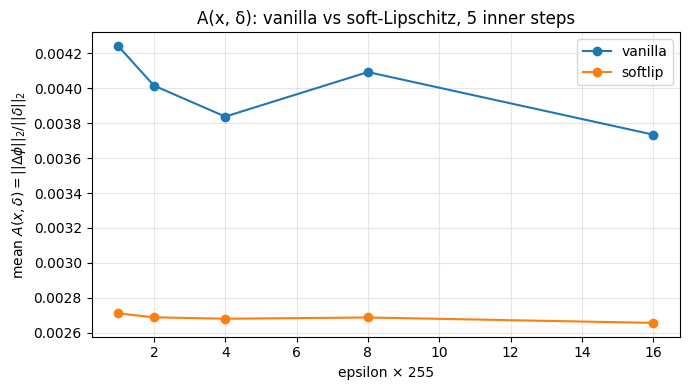

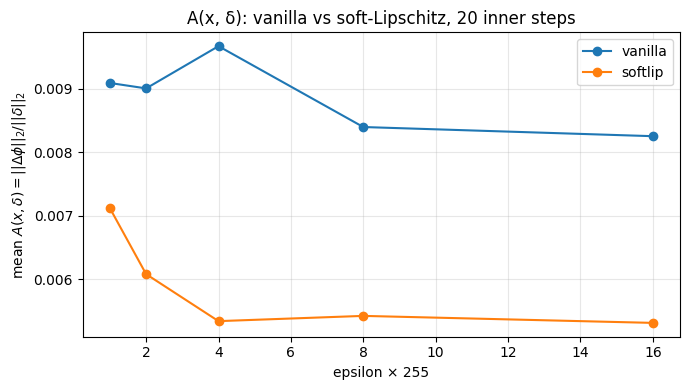

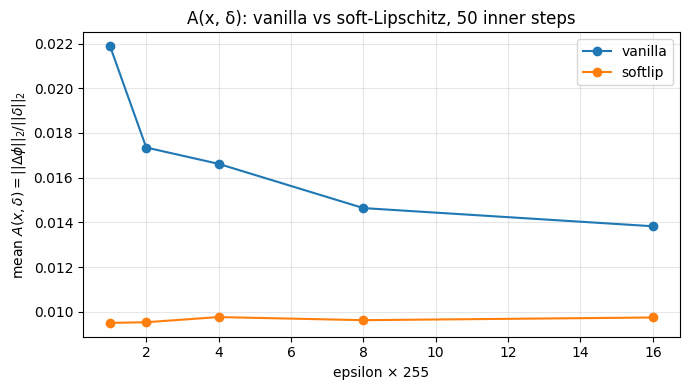

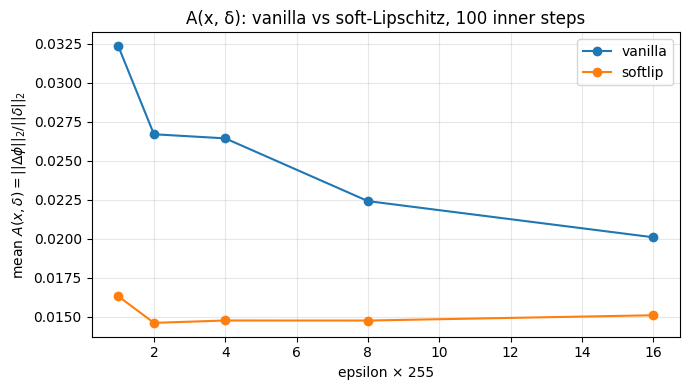

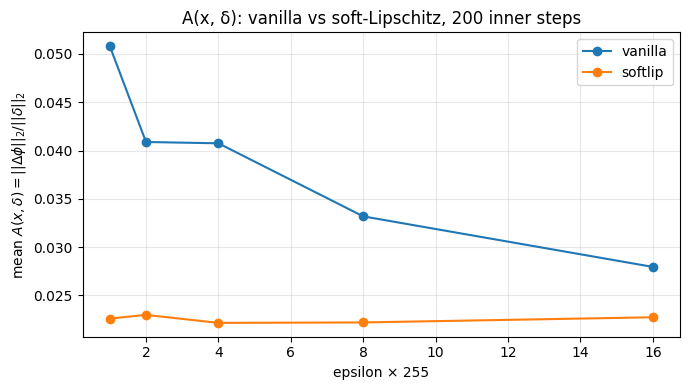

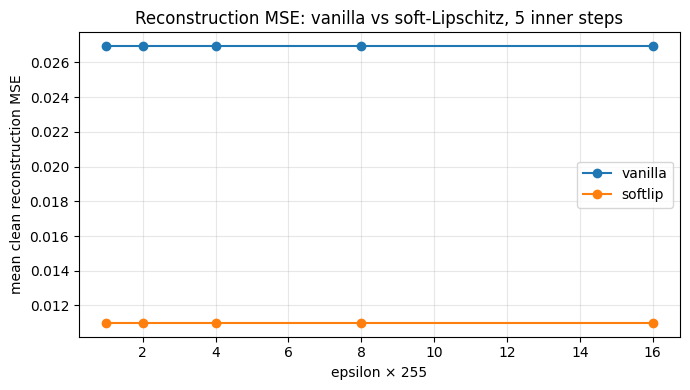

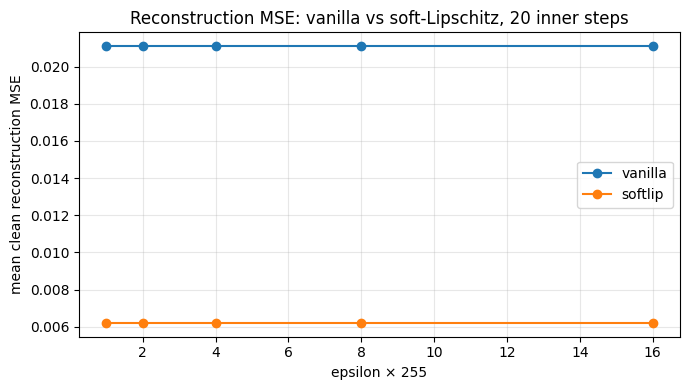

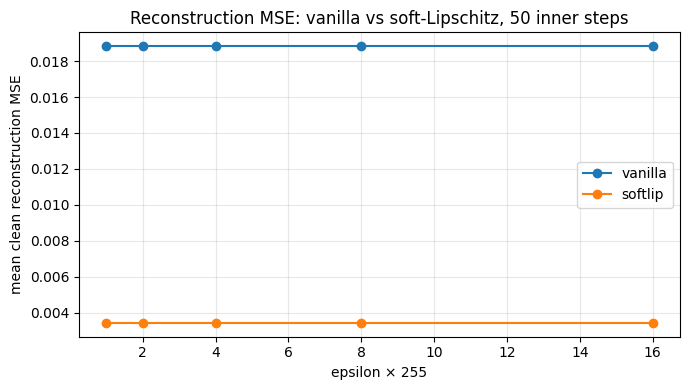

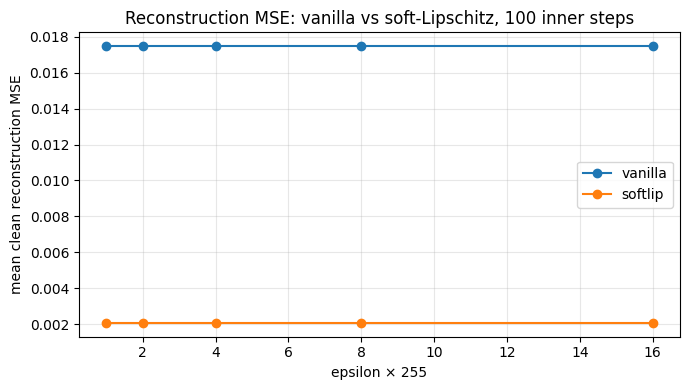

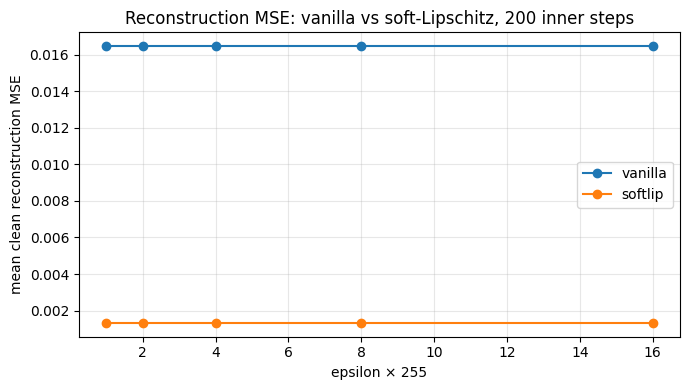

In [11]:
# ---- Compare A(x, δ): vanilla vs soft-Lipschitz ----

A_COMPARE_FIT_STEPS_LIST = [5, 20, 50, 100, 200]
A_COMPARE_EPS_LIST = [1/255, 2/255, 4/255, 8/255, 16/255]
A_COMPARE_N_IMAGES = 32
A_COMPARE_FIT_LR = FIT_LR
A_COMPARE_NOISE_MODE = "sign"
A_COMPARE_RANDOM_SEED = SEED

if vanilla is None:
    raise RuntimeError("vanilla model is missing.")

if softlip is None:
    raise RuntimeError("softlip model is missing.")

images_A_compare = mnist_images[:A_COMPARE_N_IMAGES].to(DEVICE)

all_compare_rows = []

models_to_compare = {
    "vanilla": vanilla,
    "softlip": softlip,
}

for model_name, model in models_to_compare.items():
    for fit_steps in A_COMPARE_FIT_STEPS_LIST:
        print(f"\nRunning {model_name}: fit_steps={fit_steps}")

        # Reset seed so vanilla and softlip get the same random perturbations
        torch.manual_seed(A_COMPARE_RANDOM_SEED)

        for eps in A_COMPARE_EPS_LIST:
            result = compute_A_for_eps(
                model=model,
                images=images_A_compare,
                eps=eps,
                fit_steps=fit_steps,
                fit_lr=A_COMPARE_FIT_LR,
                noise_mode=A_COMPARE_NOISE_MODE,
                device=DEVICE,
            )

            A_values = result["A_values"]

            all_compare_rows.append({
                "model": model_name,
                "fit_steps": fit_steps,
                "eps": result["eps"],
                "eps_255": result["eps_255"],
                "mean_A": float(A_values.mean().item()),
                "median_A": float(A_values.median().item()),
                "std_A": float(A_values.std().item()),
                "min_A": float(A_values.min().item()),
                "max_A": float(A_values.max().item()),
                "mean_||delta||_2": float(result["delta_l2"].mean().item()),
                "mean_||delta_phi||_2": float(result["delta_phi_l2"].mean().item()),
                "mean_mse_clean": float(result["mse_clean"].mean().item()),
                "mean_mse_pert": float(result["mse_pert"].mean().item()),
            })

df_A_compare = pd.DataFrame(all_compare_rows)

print("A(x, δ) comparison: vanilla vs soft-Lipschitz")
display(df_A_compare)


# Plot mean_A for each model and inner-step budget
for fit_steps in A_COMPARE_FIT_STEPS_LIST:
    plt.figure(figsize=(7, 4))

    for model_name in models_to_compare.keys():
        df_sub = df_A_compare[
            (df_A_compare["model"] == model_name) &
            (df_A_compare["fit_steps"] == fit_steps)
        ]

        plt.plot(
            df_sub["eps_255"],
            df_sub["mean_A"],
            marker="o",
            label=model_name,
        )

    plt.xlabel("epsilon × 255")
    plt.ylabel(r"mean $A(x,\delta)=||\Delta\phi||_2 / ||\delta||_2$")
    plt.title(f"A(x, δ): vanilla vs soft-Lipschitz, {fit_steps} inner steps")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Plot reconstruction MSE for each model and inner-step budget
for fit_steps in A_COMPARE_FIT_STEPS_LIST:
    plt.figure(figsize=(7, 4))

    for model_name in models_to_compare.keys():
        df_sub = df_A_compare[
            (df_A_compare["model"] == model_name) &
            (df_A_compare["fit_steps"] == fit_steps)
        ]

        plt.plot(
            df_sub["eps_255"],
            df_sub["mean_mse_clean"],
            marker="o",
            label=model_name,
        )

    plt.xlabel("epsilon × 255")
    plt.ylabel("mean clean reconstruction MSE")
    plt.title(f"Reconstruction MSE: vanilla vs soft-Lipschitz, {fit_steps} inner steps")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()